### 
Purpose
Evaluate whether XGBoost can outperform Random Forest and Logistic Regression for fraud detection.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

###
The required libraries were imported for model training, evaluation, and visualization. XGBoost will be used as an advanced ensemble learning algorithm for fraud detection.

In [7]:
import pandas as pd

from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("data/raw/creditcard.csv")

# Features
X = df.drop("Class", axis=1)

# Target
y = df["Class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (227845, 30)
X_test shape : (56962, 30)
y_train shape: (227845,)
y_test shape : (56962,)


### 
The training and testing datasets were loaded successfully and are ready for model development.

### XGBoost Model

In [9]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

### 
An XGBoost classifier was initialized with 100 boosting rounds and a learning rate of 0.1. These parameters provide a balance between model complexity and generalization performance.

### Train Model

In [10]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 
The XGBoost model was trained using the training dataset. During training, successive trees were built to correct errors made by previous trees, allowing the model to learn complex fraud patterns.

### Predictions

In [12]:
y_pred_xgb = xgb_model.predict(
    X_test
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

### 
Predictions and fraud probabilities were generated for the testing dataset. These outputs will be used to evaluate model performance.

### Classification Report

In [13]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



###
The XGBoost model achieved a precision of 90%, recall of 80%, and an F1-score of 84% for the fraud class. These results indicate that the model was highly accurate when predicting fraudulent transactions while successfully detecting a large proportion of fraud cases. The strong F1-score suggests a good balance between precision and recall, making XGBoost an effective model for fraud detection.

### Confusion Matrix

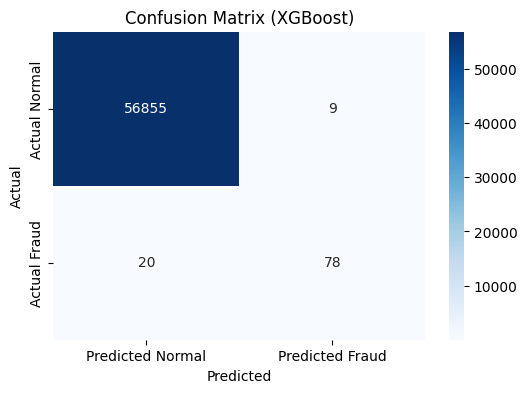

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Normal",
        "Predicted Fraud"
    ],
    yticklabels=[
        "Actual Normal",
        "Actual Fraud"
    ]
)

plt.title(
    "Confusion Matrix (XGBoost)"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 
The confusion matrix indicates that the XGBoost model achieved strong classification performance. The model correctly identified 56,855 legitimate transactions and 78 fraudulent transactions. It generated only 9 false positive predictions, meaning that very few legitimate transactions were incorrectly flagged as fraud. Additionally, the model missed 20 fraudulent transactions, which represents the fraud cases that were not detected. Overall, XGBoost demonstrated a strong ability to distinguish between legitimate and fraudulent transactions while maintaining a low false positive rate.

### ROC-AUC Score


In [15]:
auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(
    "ROC-AUC Score:",
    auc_xgb
)

ROC-AUC Score: 0.9601157218655612


### 
The XGBoost model achieved a ROC-AUC score of 0.9601, indicating excellent ability to distinguish between fraudulent and legitimate transactions across different classification thresholds. A ROC-AUC value close to 1.0 suggests that the model is highly effective at ranking fraudulent transactions higher than legitimate transactions. Although the score is slightly lower than both the SMOTE-enhanced Logistic Regression model (0.9775) and the Random Forest model (0.9630), it still demonstrates strong discriminatory performance and confirms that XGBoost is a capable fraud detection model.

### ROC Curve

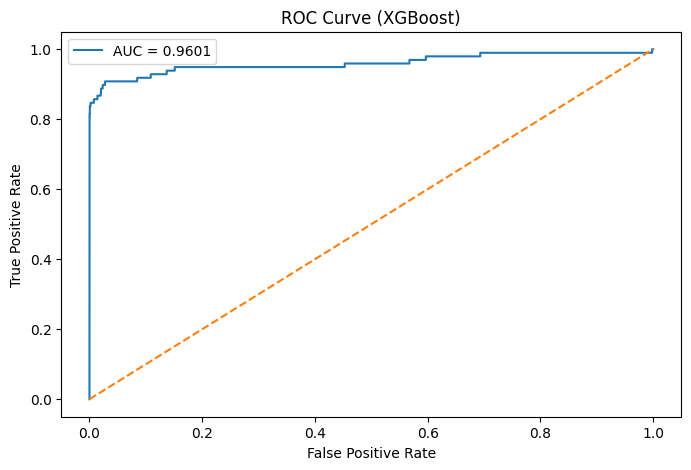

In [16]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_xgb:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve (XGBoost)"
)

plt.legend()

plt.show()

### 
The ROC curve for the XGBoost model lies well above the diagonal reference line and remains close to the top-left corner of the plot, indicating strong classification performance. This suggests that the model is able to achieve a high true positive rate (fraud detection rate) while maintaining a low false positive rate across different classification thresholds. The ROC-AUC score of 0.9601 further confirms that the model has an excellent ability to distinguish between fraudulent and legitimate transactions. Although the curve demonstrates strong discriminatory power, its performance is slightly lower than that of the Random Forest model evaluated earlier.

### Compare All Models

In [17]:
comparison = pd.DataFrame({
    "Metric":[
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Logistic Regression":[
        0.82,
        0.65,
        0.73,
        0.9525
    ],

    "Logistic + SMOTE":[
        0.13,
        0.90,
        0.23,
        0.9775
    ],

    "Random Forest":[
        0.94,
        0.82,
        0.87,
        0.9630
    ],

    "XGBoost":[
        0.90,
        0.80,
        0.84,
        0.9601
    ]
})

comparison

,Metric,Logistic Regression,Logistic + SMOTE,Random Forest,XGBoost
0,Precision,0.8200,0.1300,0.940,0.9000
1,Recall,0.6500,0.9000,0.820,0.8000
2,F1-Score,0.7300,0.2300,0.870,0.8400
3,ROC-AUC,0.9525,0.9775,0.963,0.9601


### 
The comparison table summarizes the performance of all evaluated models and highlights the strengths and weaknesses of each approach. The baseline Logistic Regression model provided reasonable performance but missed a significant number of fraud cases. Applying SMOTE substantially improved recall and ROC-AUC, but resulted in a large number of false positive predictions and a very low precision score. Both Random Forest and XGBoost achieved strong overall performance, with Random Forest producing the highest precision (94%), highest F1-score (87%), and fewer false positives. Based on the evaluated metrics, Random Forest provided the best balance between fraud detection capability and false alarm reduction, making it the strongest candidate for deployment.

### Notebook Conclusion

###
The XGBoost model was evaluated as an advanced ensemble learning algorithm for fraud detection and compared against Logistic Regression, Logistic Regression with SMOTE, and Random Forest. The model achieved strong performance, with a precision of 90%, recall of 80%, F1-score of 84%, and ROC-AUC score of 0.9601. Although XGBoost demonstrated excellent discriminatory ability and effective fraud detection, Random Forest slightly outperformed it across key evaluation metrics, including precision, recall, F1-score, and false positive rate. Consequently, Random Forest was selected as the preferred model for this project because it offered the best balance between detecting fraudulent transactions and minimizing unnecessary fraud alerts. These results demonstrate the importance of comparing multiple machine learning models and evaluating them using appropriate performance metrics when developing real-world fraud detection systems